In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [3]:
## Read the data
data = pd.read_csv("PSCompPars_2025.10.16_07.48.29.csv", delimiter= ",", skiprows = 10)
print(data.columns)

## Load the data to arrays
name = data["pl_name"]
orb_pd = data["pl_orbper"]
dens = data["pl_dens"]
rad = data["pl_rade"]
mass = data["pl_bmasse"]
ifmass = data["pl_bmassprov"]

Index(['pl_name', 'pl_orbper', 'pl_rade', 'pl_bmasse', 'pl_bmassprov',
       'pl_dens'],
      dtype='object')


## Analysis with all the data

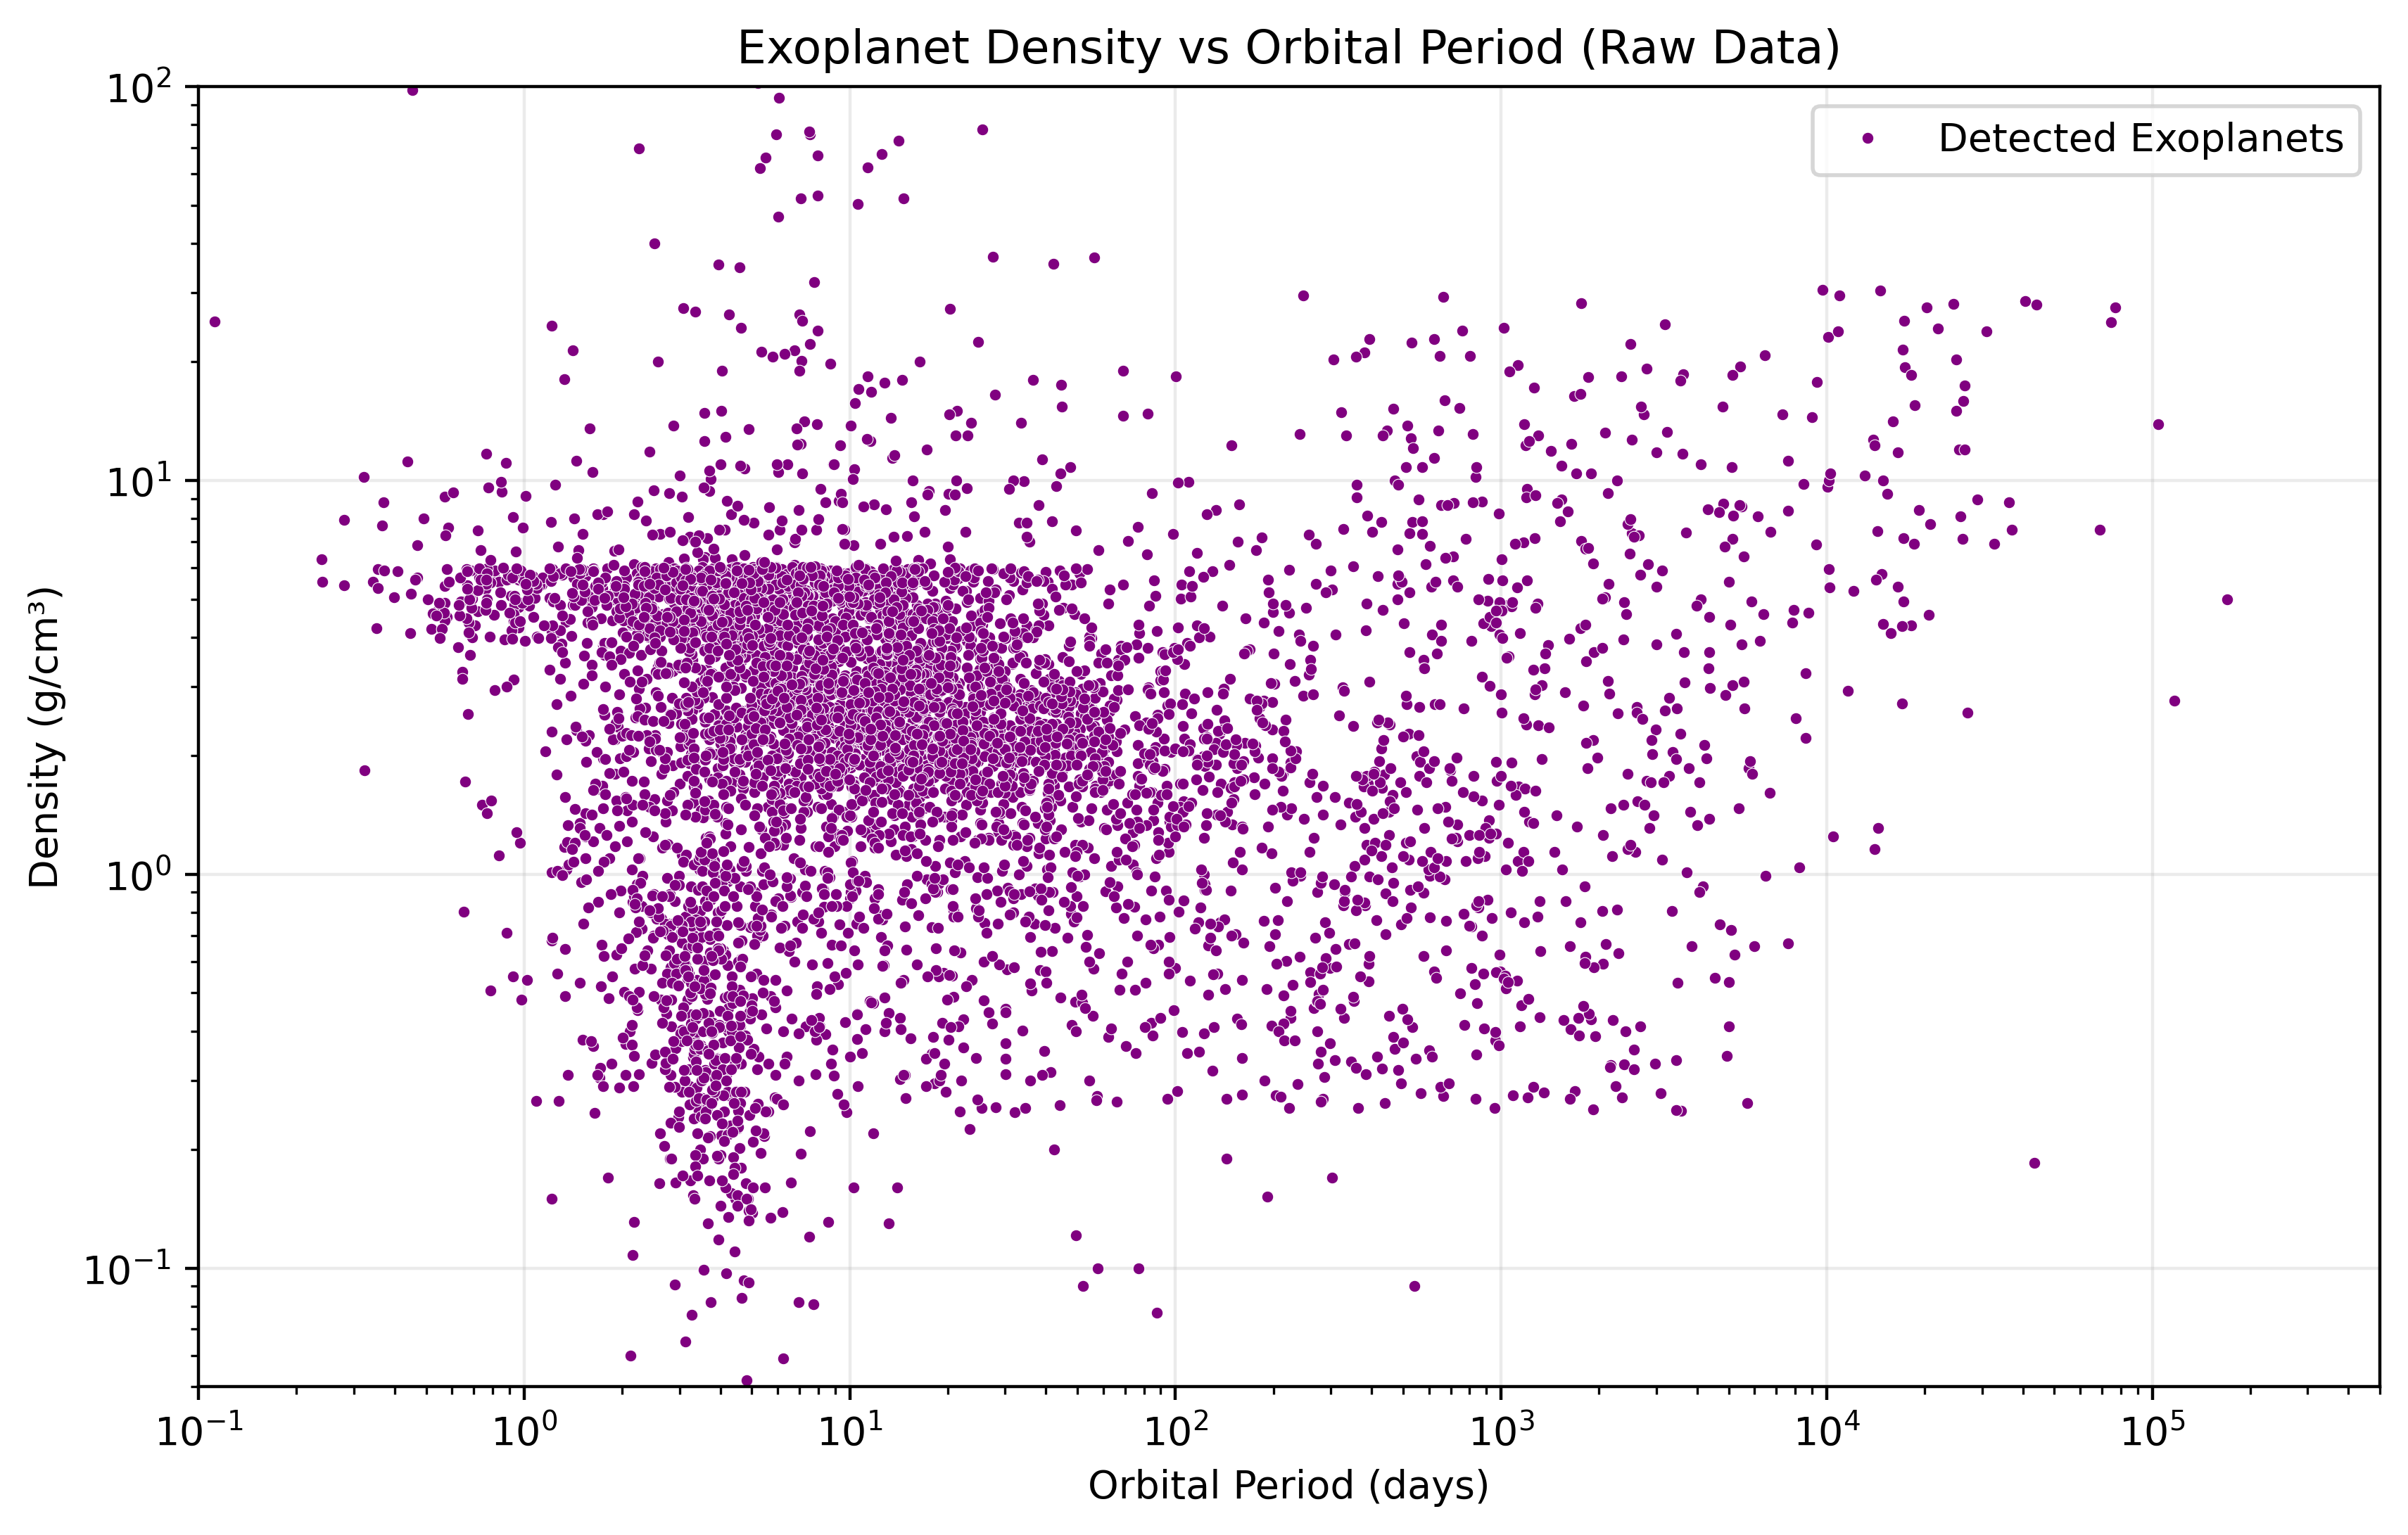

In [4]:
##_______________Plot the raw data_____________________
plt.figure(dpi=400, figsize=(10, 6))
plt.loglog(orb_pd, dens, ls=" ", marker="o", ms=3, mfc='purple', mec='white', mew=0.2, label = 'Detected Exoplanets')
plt.xlim(left=1e-1, right=5e5)
plt.ylim(bottom=5e-2, top=1e2)
plt.grid(alpha=0.25)
plt.xlabel("Orbital Period (days)")
plt.ylabel("Density (g/cm³)")
plt.title("Exoplanet Density vs Orbital Period (Raw Data)")
plt.legend()
plt.show()

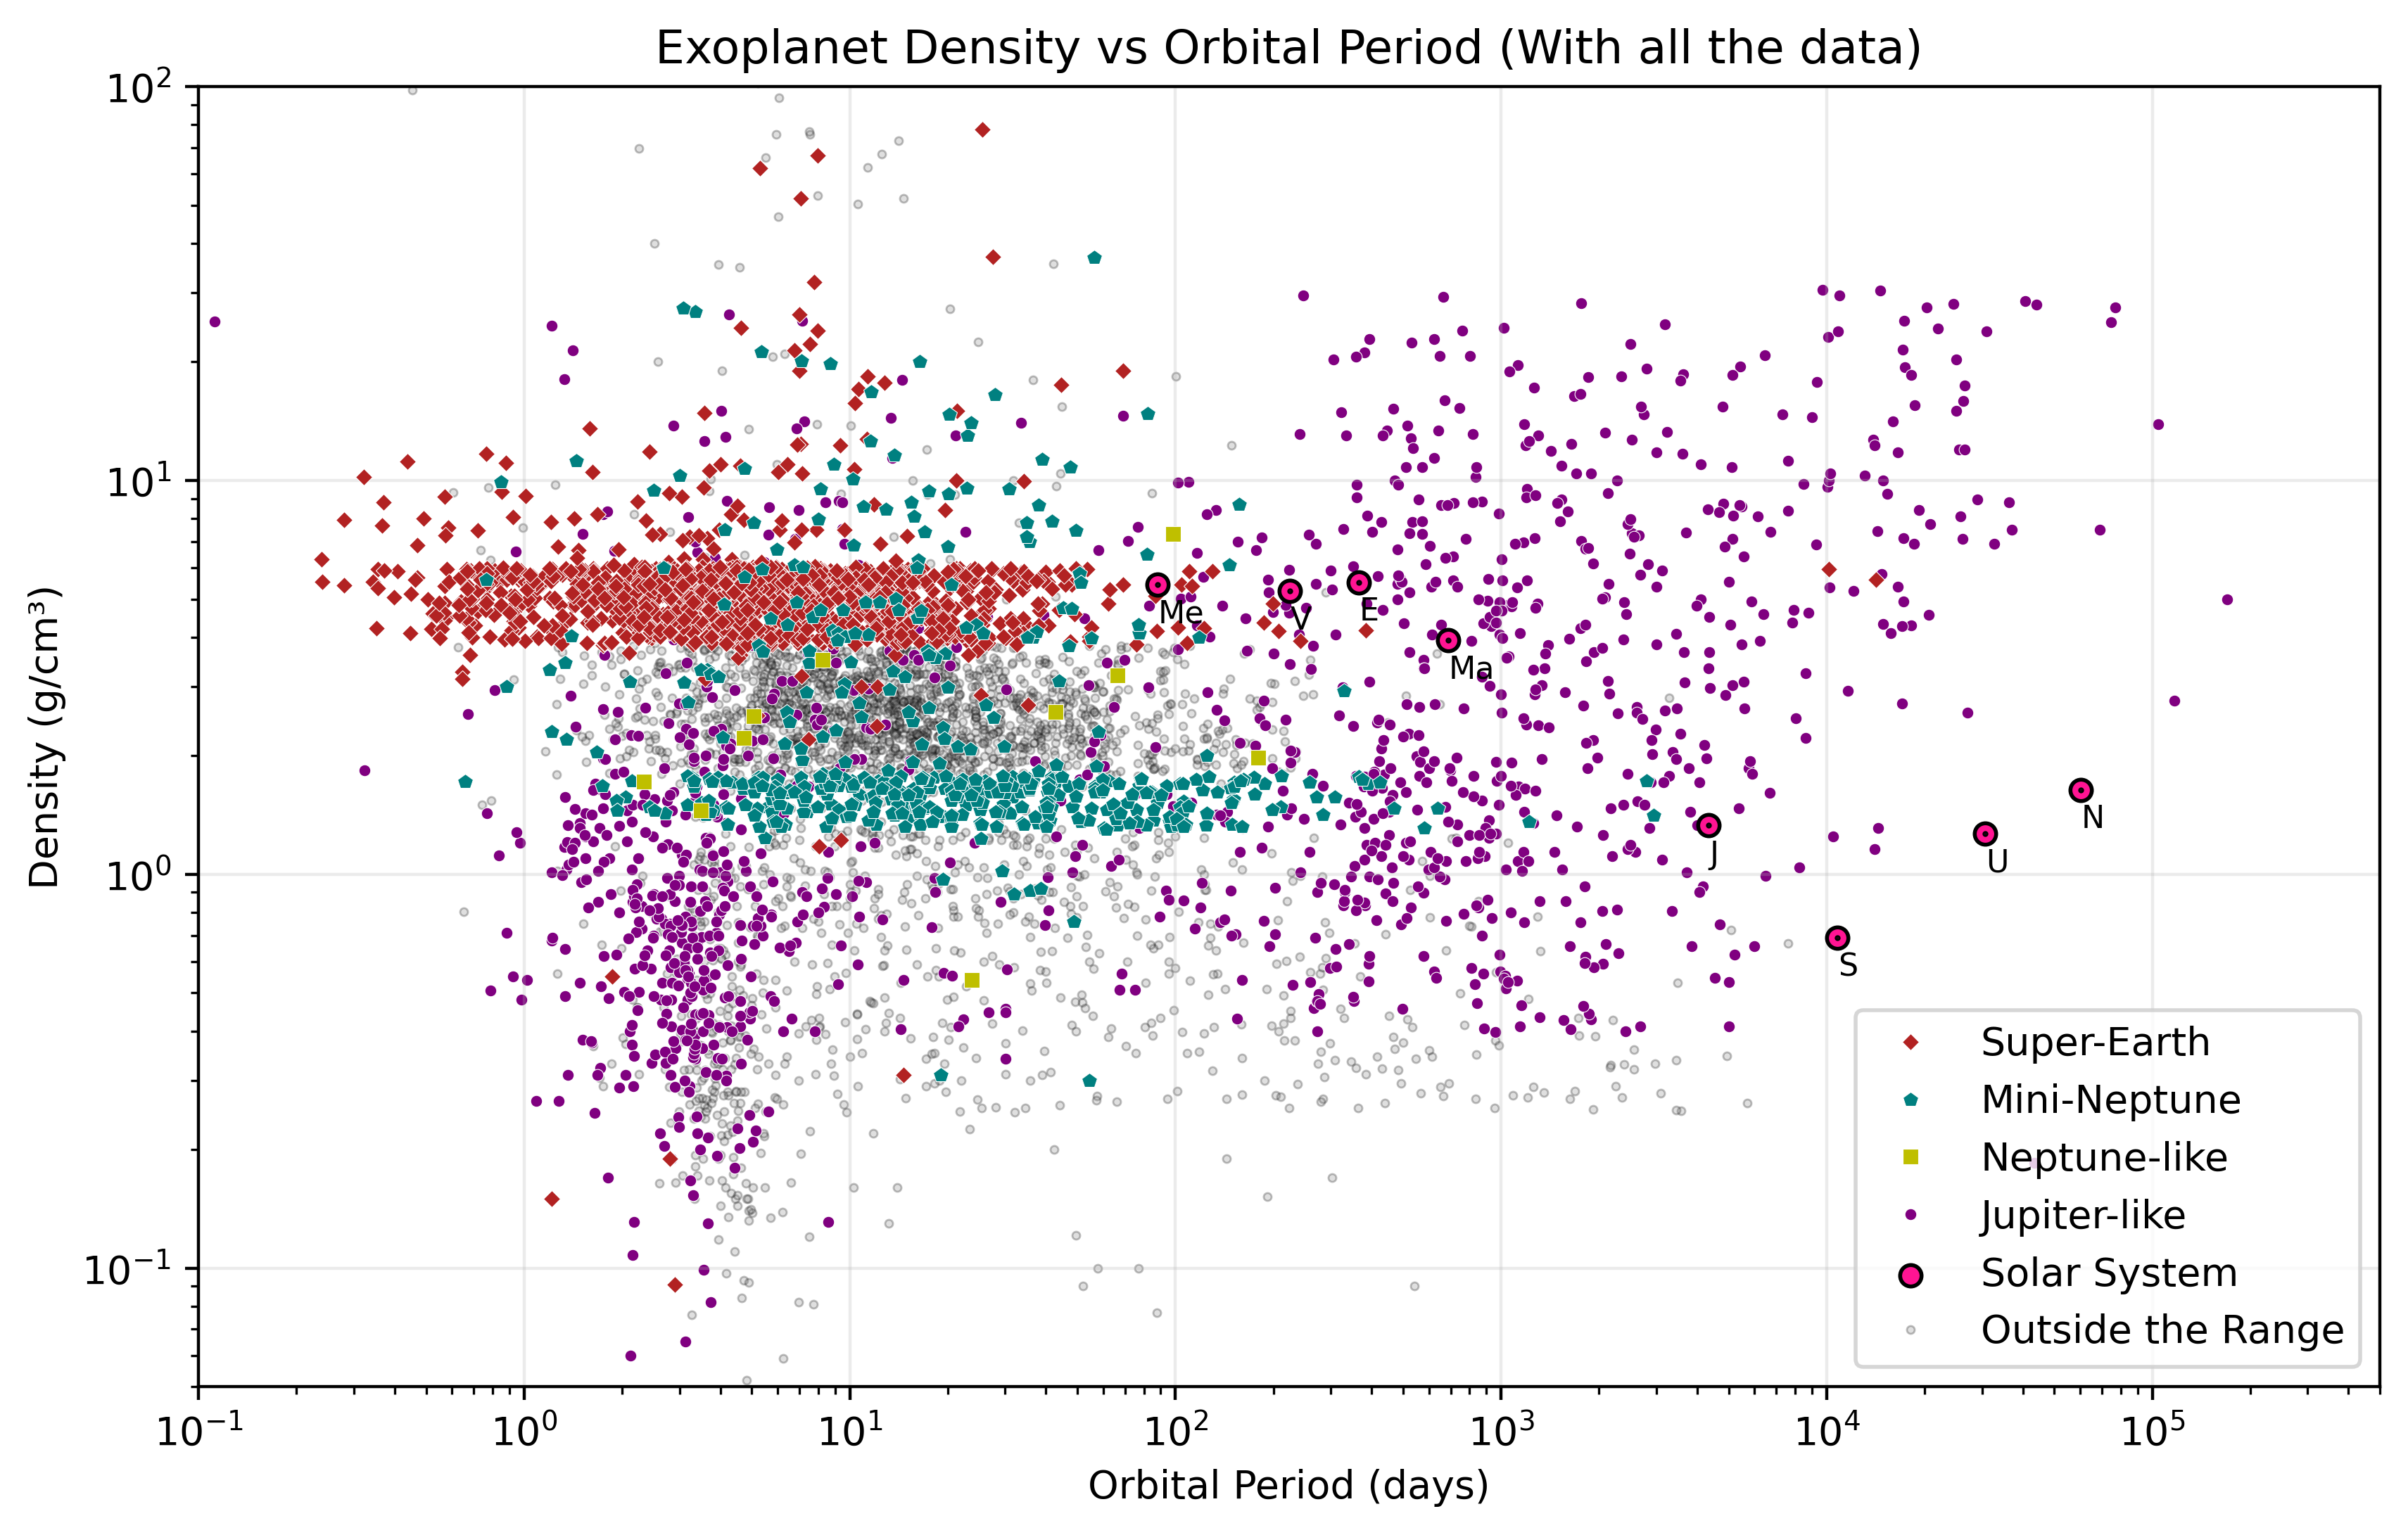

In [5]:
##_______________Plot the data_____________________
plt.figure(dpi=400, figsize=(10, 6))

## Masks for different planet types
mask1 = (mass < 10) & (rad < 1.75)                                      # Super-Earth
mask2 = (mass >= 10) & (mass < 50) & (rad >= 1.75) & (rad < 4)          # Mini-Neptune
mask3 = (mass >= 50) & (mass < 200) & (rad >= 4) & (rad < 6)            # Neptune-like
mask4 = (mass >= 200) & (rad >= 6)                                      # Jupiter-like

## Plot each category
plt.loglog(orb_pd[mask1], dens[mask1], ls=" ", marker="D", ms=3, mfc='firebrick', mec='white', mew=0.2, label="Super-Earth", zorder = 2)
plt.loglog(orb_pd[mask2], dens[mask2], ls=" ", marker="p", ms=4, mfc='teal', mec='white', mew=0.2, label="Mini-Neptune", zorder = 3)
plt.loglog(orb_pd[mask3], dens[mask3], ls=" ", marker="s", ms=4, mfc='y', mec='white', mew=0.2, label="Neptune-like", zorder = 4)
plt.loglog(orb_pd[mask4], dens[mask4], ls=" ", marker="o", ms=3, mfc='purple', mec='white', mew=0.2, label="Jupiter-like", zorder = 1)

## Solar system data
solar_names = ["Me", "V", "E", "Ma", "J", "S", "U", "N"]
solar_orb = [87.97, 224.70, 365.25, 686.98, 4332.59, 10759.22, 30685.4, 60190.0]
solar_dens = [5.43, 5.24, 5.51, 3.93, 1.33, 0.69, 1.27, 1.64]

## Overlay on existing plot
plt.scatter(solar_orb, solar_dens, c='deeppink', edgecolor='black', s=30, zorder=5, label='Solar System')
plt.scatter(solar_orb, solar_dens, marker= ".", color = 'k', zorder = 6, s = 1)
for name, x, y in zip(solar_names, solar_orb, solar_dens): plt.text(x*1.005, y*0.8, name, fontsize=8)

## Mask for planets outside the above categories
mask_other = ~(mask1 | mask2 | mask3 | mask4)

## Residual data
plt.loglog(orb_pd[mask_other], dens[mask_other], ls="", marker=".", ms=4, mfc='gray', mec='black', mew=0.5, zorder = 0, alpha = 0.25, label="Outside the Range")

## Adjust plot appearance
plt.xlim(left=1e-1, right=5e5)
plt.ylim(bottom=5e-2, top=1e2)
plt.grid(alpha=0.25)
plt.xlabel("Orbital Period (days)")
plt.ylabel("Density (g/cm³)")
plt.title("Exoplanet Density vs Orbital Period (With all the data)")
plt.legend()
plt.show()


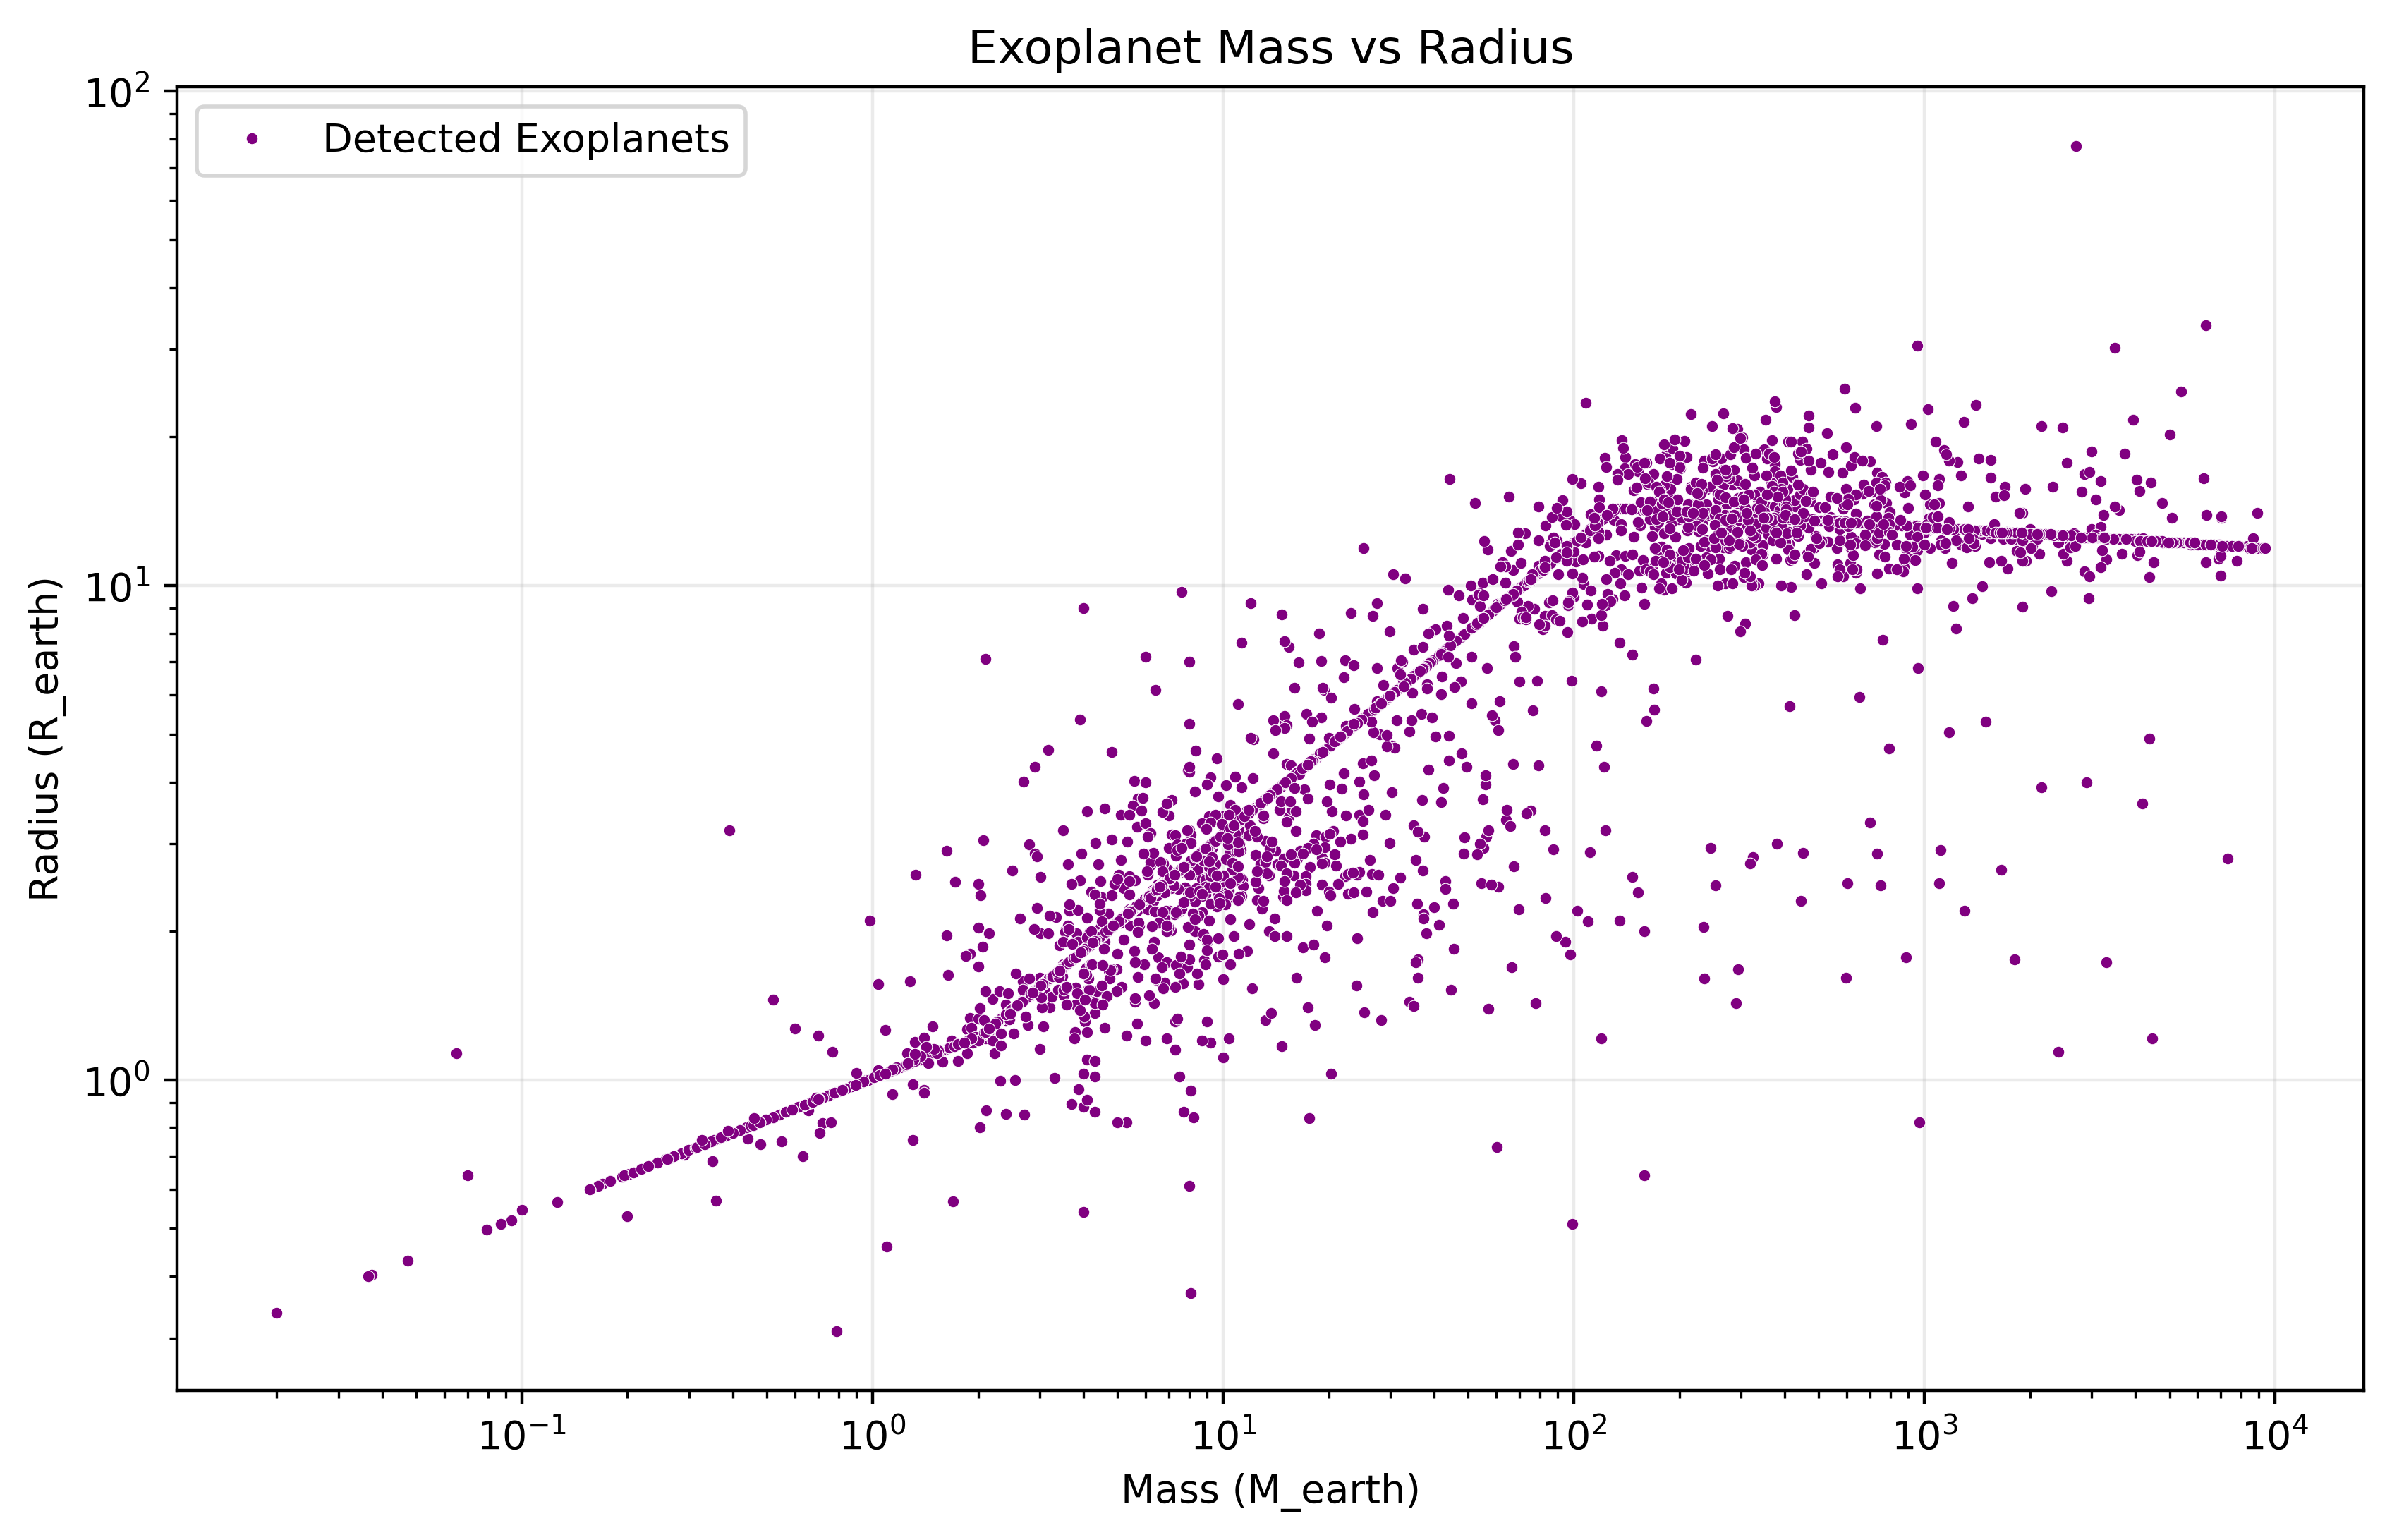

In [9]:
##_______________Plot the raw data_____________________
plt.figure(dpi=400, figsize=(10, 6))
plt.loglog(mass, rad, ls=" ", marker="o", ms=3, mfc='purple', mec='white', mew=0.2, label = 'Detected Exoplanets')
plt.grid(alpha=0.25)
plt.xlabel("Mass (M_earth)")
plt.ylabel("Radius (R_earth)")
plt.title("Exoplanet Mass vs Radius")
plt.legend()
plt.show()

## Analysis with the planets which has confirmed mass and radius

Original dataset size: 6028
Filtered dataset size: 1926


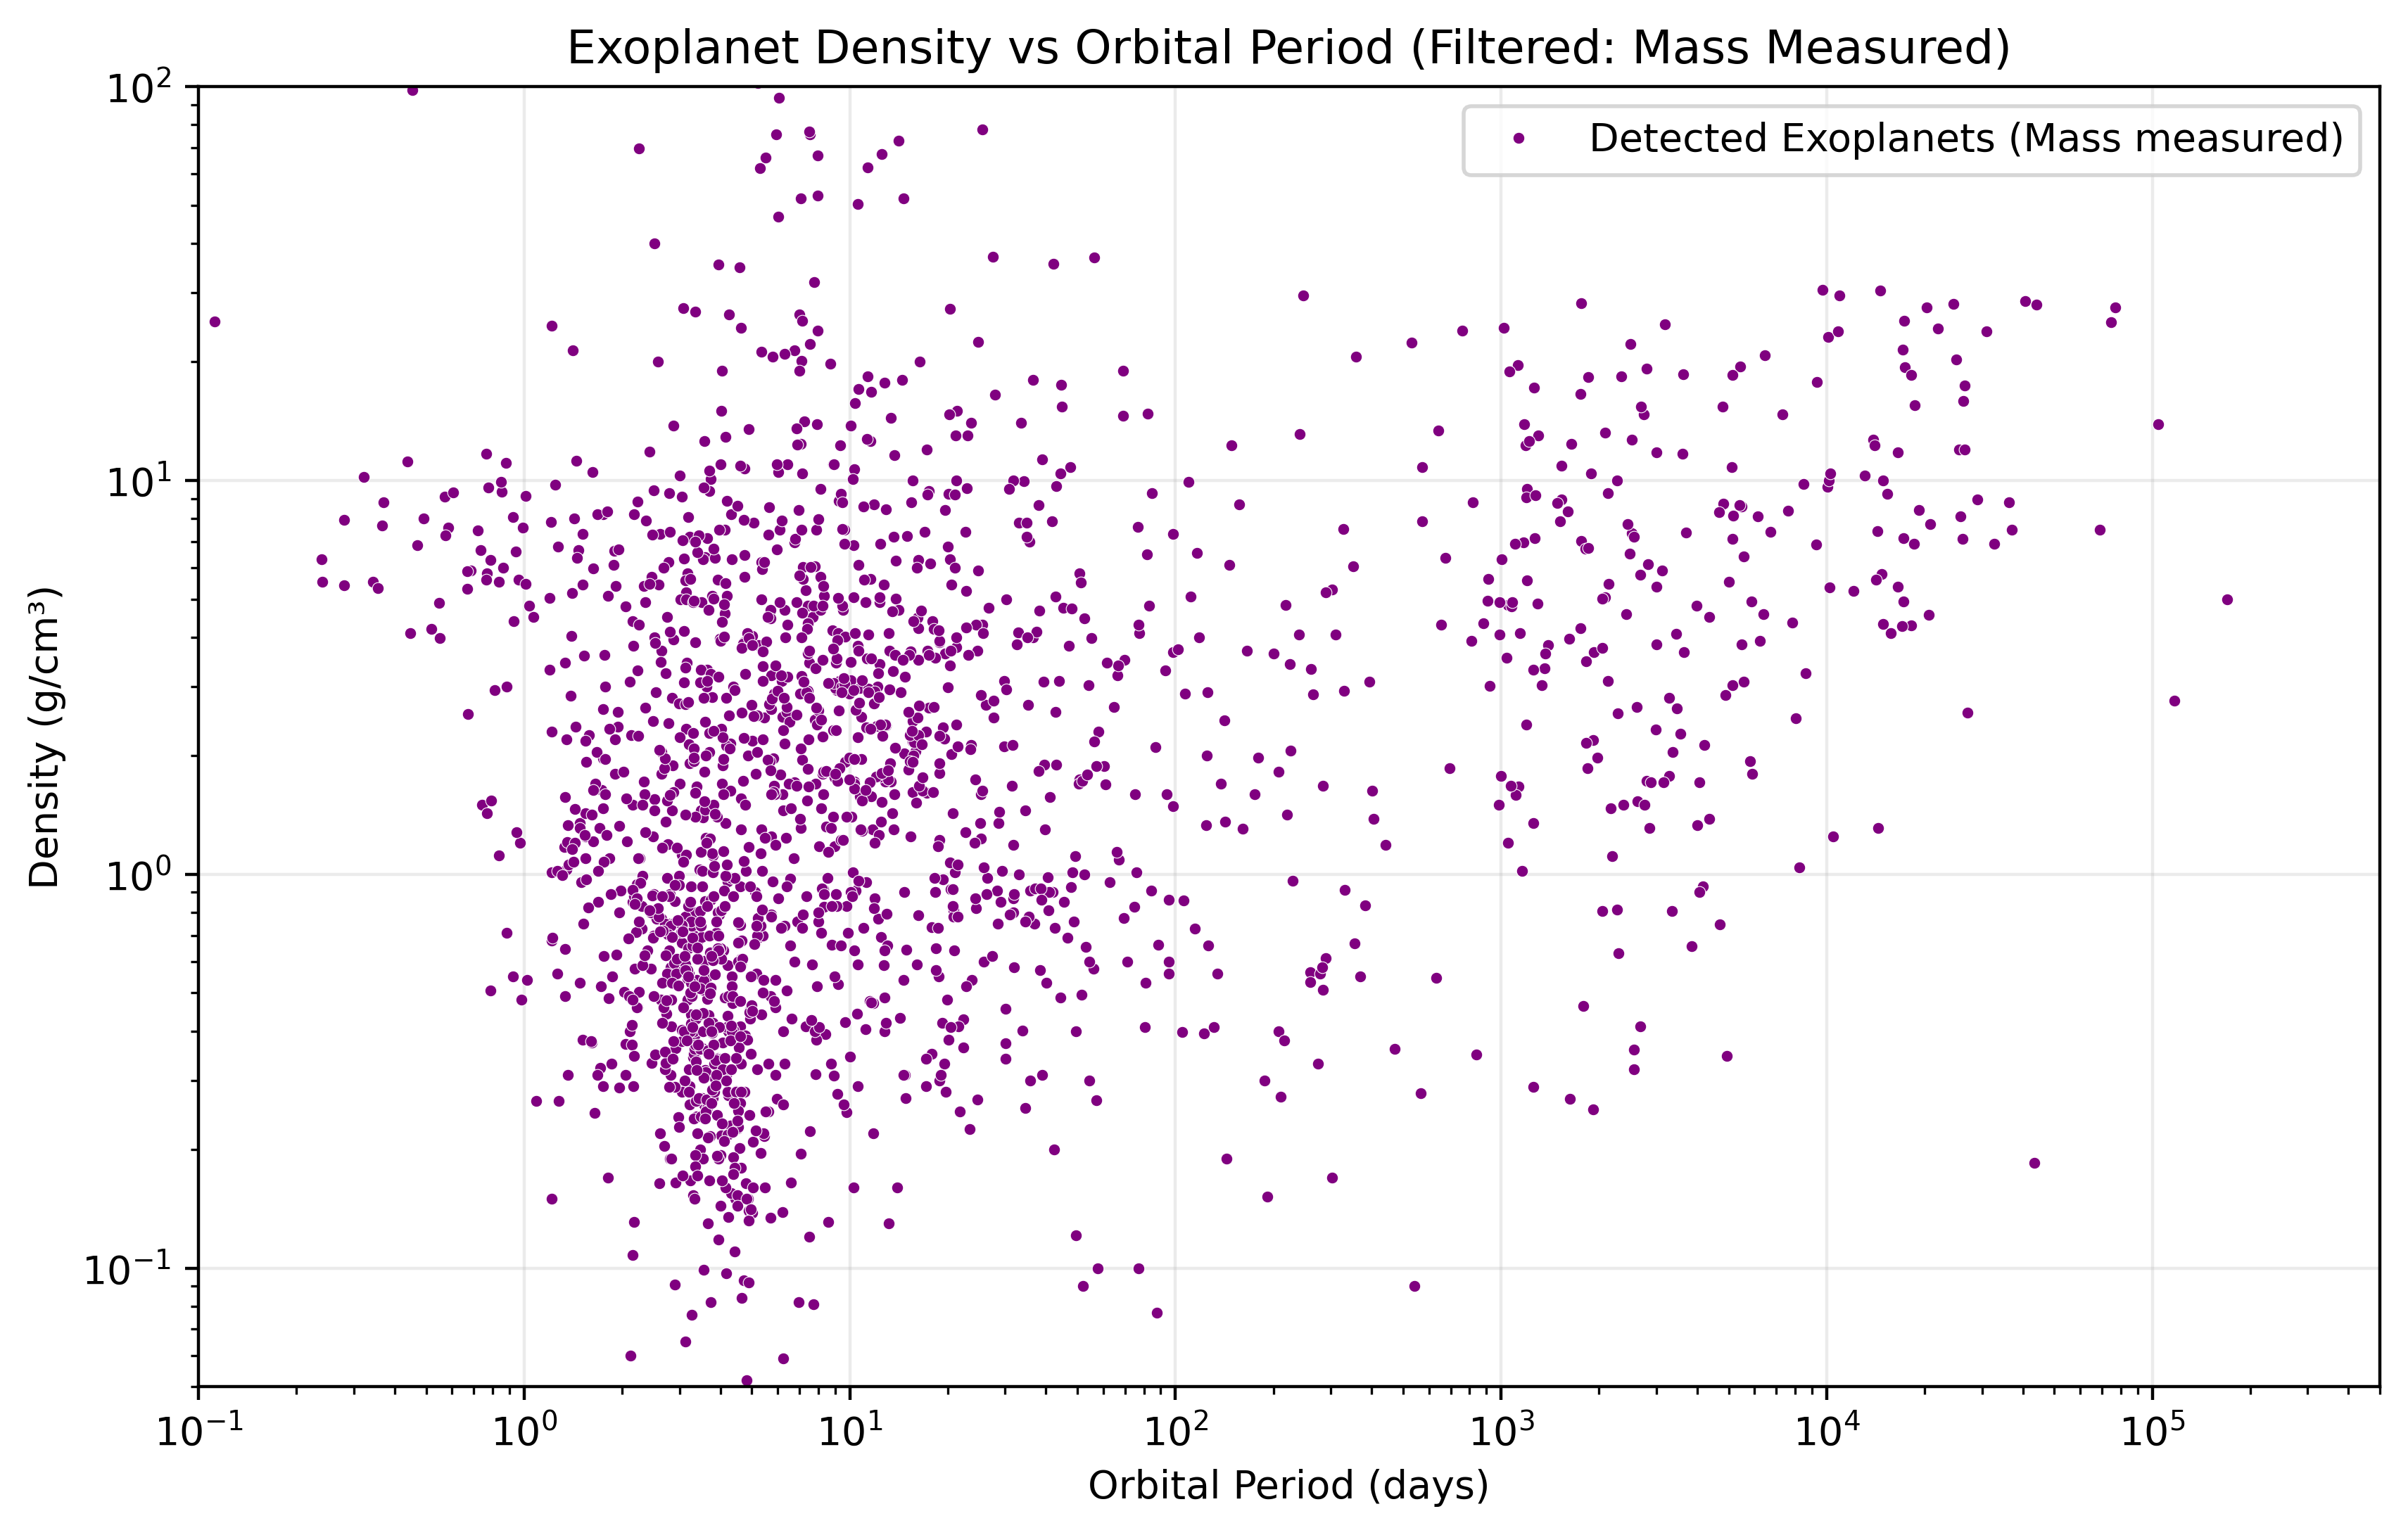

In [7]:
## Filter the data
## Keep only planets where ifmass == "Mass" and orb_pd is not null
mask = (ifmass == "Mass") & (orb_pd.notna())
filtered_data = data[mask]

## Update the arrays with filtered data
name_filtered = filtered_data["pl_name"]
orb_pd_filtered = filtered_data["pl_orbper"]
dens_filtered = filtered_data["pl_dens"]
rad_filtered = filtered_data["pl_rade"]
mass_filtered = filtered_data["pl_bmasse"]

print(f"Original dataset size: {len(data)}")
print(f"Filtered dataset size: {len(filtered_data)}")

##_______________Plot the filtered data_____________________
plt.figure(dpi=400, figsize=(10, 6))
plt.loglog(orb_pd_filtered, dens_filtered, ls=" ", marker="o", ms=3, mfc='purple', mec='white', mew=0.2, label = 'Detected Exoplanets (Mass measured)')
plt.xlim(left=1e-1, right=5e5)
plt.ylim(bottom=5e-2, top=1e2)
plt.grid(alpha=0.25)
plt.xlabel("Orbital Period (days)")
plt.ylabel("Density (g/cm³)")
plt.title("Exoplanet Density vs Orbital Period (Filtered: Mass Measured)")
plt.legend()
plt.show()

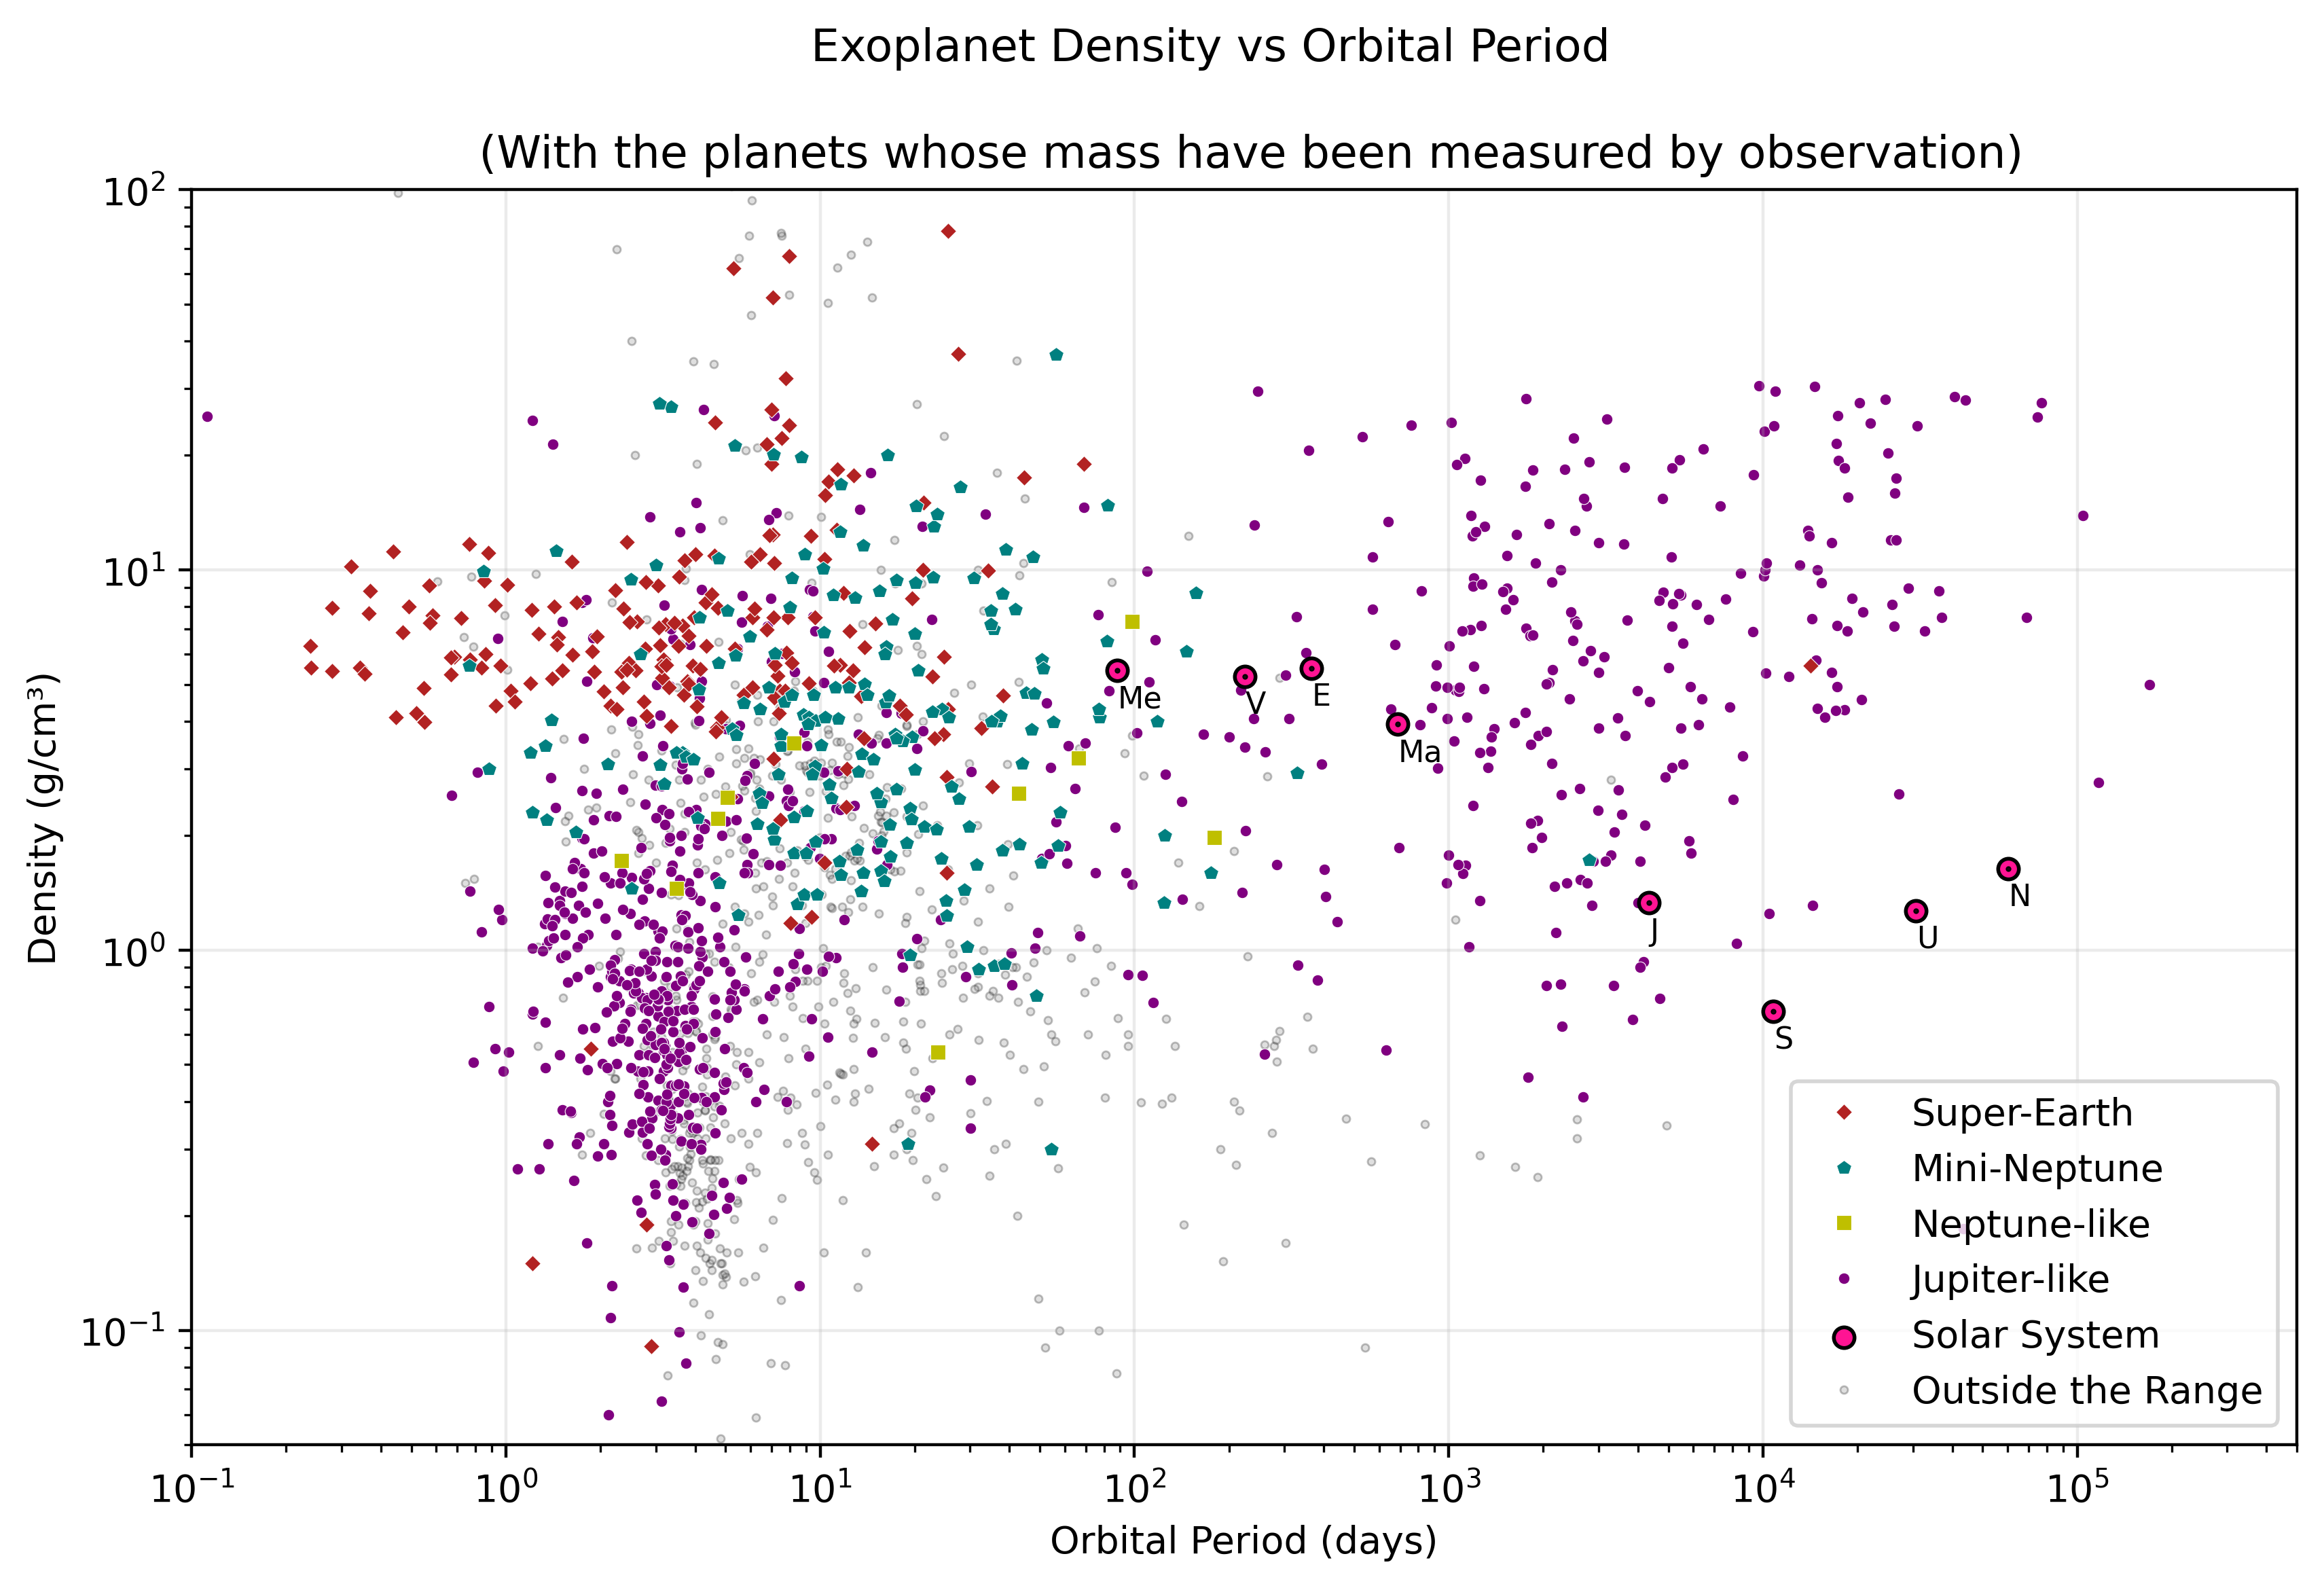

In [8]:
##_______________Plot the data_____________________
plt.figure(dpi=400, figsize=(10, 6))

## Masks for different planet types
mask1 = (mass < 10) & (rad < 1.75)                                      # Super-Earth
mask2 = (mass >= 10) & (mass < 50) & (rad >= 1.75) & (rad < 4)          # Mini-Neptune
mask3 = (mass >= 50) & (mass < 200) & (rad >= 4) & (rad < 6)            # Neptune-like
mask4 = (mass >= 200) & (rad >= 6)                                      # Jupiter-like

## Plot each category
plt.loglog(orb_pd_filtered[mask1], dens_filtered[mask1], ls=" ", marker="D", ms=3, mfc='firebrick', mec='white', mew=0.2, label="Super-Earth", zorder = 2)
plt.loglog(orb_pd_filtered[mask2], dens_filtered[mask2], ls=" ", marker="p", ms=4, mfc='teal', mec='white', mew=0.2, label="Mini-Neptune", zorder = 3)
plt.loglog(orb_pd_filtered[mask3], dens_filtered[mask3], ls=" ", marker="s", ms=4, mfc='y', mec='white', mew=0.2, label="Neptune-like", zorder = 4)
plt.loglog(orb_pd_filtered[mask4], dens_filtered[mask4], ls=" ", marker="o", ms=3, mfc='purple', mec='white', mew=0.2, label="Jupiter-like", zorder = 1)

## Solar system data
solar_names = ["Me", "V", "E", "Ma", "J", "S", "U", "N"]
solar_orb = [87.97, 224.70, 365.25, 686.98, 4332.59, 10759.22, 30685.4, 60190.0]
solar_dens = [5.43, 5.24, 5.51, 3.93, 1.33, 0.69, 1.27, 1.64]

## Overlay on existing plot
plt.scatter(solar_orb, solar_dens, c='deeppink', edgecolor='black', s=30, zorder=5, label='Solar System')
plt.scatter(solar_orb, solar_dens, marker= ".", color = 'k', zorder = 6, s = 1)
for name, x, y in zip(solar_names, solar_orb, solar_dens): plt.text(x*1.005, y*0.8, name, fontsize=8)

## Mask for planets outside the above categories
mask_other = ~(mask1 | mask2 | mask3 | mask4)

## Residual data
plt.loglog(orb_pd_filtered[mask_other], dens_filtered[mask_other], ls="", marker=".", ms=4, mfc='gray', mec='black', mew=0.5, zorder = 0, alpha = 0.25, label="Outside the Range")

## Adjust plot appearance
plt.xlim(left=1e-1, right=5e5)
plt.ylim(bottom=5e-2, top=1e2)
plt.grid(alpha=0.25)
plt.xlabel("Orbital Period (days)")
plt.ylabel("Density (g/cm³)")
plt.suptitle("Exoplanet Density vs Orbital Period")
plt.title(" (With the planets whose mass have been measured by observation)")
plt.legend()
plt.show()
